# Task 3: Part A: Pool Ball Detection

**Goal:** Train an object detector that can locate every ball on a pool table, draw a bounding box around it, and label it with its category (`Black`, `Cue`, `Dot`, `Solid`, `Striped`).

**What we will build:**
1. Explore and understand the dataset (images + COCO annotations)
2. Convert the dataset to YOLO format (what the models expect)
3. Fine-tune **YOLOv8-s** — a fast, CNN-based single-stage detector
4. Fine-tune **RT-DETR-l** — a modern Transformer-based detector
5. Compare both models on standard detection metrics (mAP, precision, recall, speed)




---
## 0. Install Dependencies




In [2]:
# Install Ultralytics (includes YOLOv8 and RT-DETR)
# Run this only once — comment it out after the first run to save time
!pip install ultralytics --quiet


[notice] A new release of pip available: 22.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import torch
print(torch.cuda.is_available())

True


In [4]:
import os
import json
import shutil
import random
from pathlib import Path
from collections import Counter

import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

from ultralytics import YOLO, RTDETR

# Reproducibility
random.seed(42)
np.random.seed(42)

print("All imports successful!")

All imports successful!


---
## 1. Data Exploration




In [5]:
# ── Paths ──────────────────────────────────────────────────────────────────
TRAIN_DIR   = Path("./train")
COCO_JSON   = TRAIN_DIR / "_annotations.coco.json"  # adjust if your filename differs

# ── Load the COCO JSON ─────────────────────────────────────────────────────
with open(COCO_JSON) as f:
    coco = json.load(f)

print(f"Total images      : {len(coco['images'])}")
print(f"Total annotations : {len(coco['annotations'])}")
print(f"\nCategories:")
for cat in coco["categories"]:
    print(f"  id={cat['id']:>3}  name={cat['name']}")

Total images      : 247
Total annotations : 7244

Categories:
  id=  0  name=balls
  id=  1  name=Black
  id=  2  name=Cue
  id=  3  name=Dot
  id=  4  name=Solid
  id=  5  name=Striped


Annotation counts per class:
  Dot       : 4427
  Solid     : 1225
  Striped   : 1105
  Cue       : 245
  Black     : 242


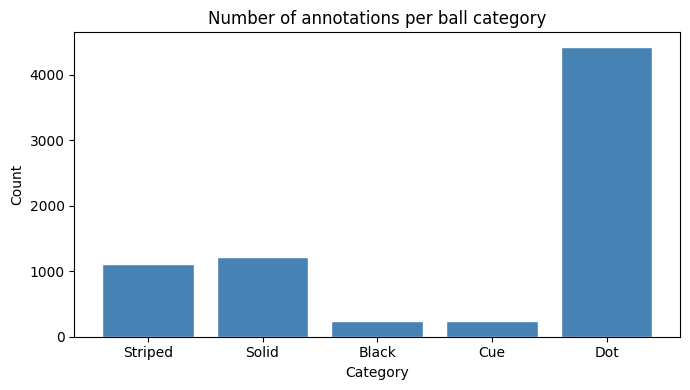

In [ ]:
# ── Build helper look-up dictionaries ──────────────────────────────────────
id_to_name = {cat["id"]: cat["name"] for cat in coco["categories"]}

id_to_file = {img["id"]: img["file_name"] for img in coco["images"]}

# ── Count annotations per category ─────────────────────────────────────────

real_cat_ids = {cat["id"] for cat in coco["categories"] if cat["name"] != "balls"}

cat_counts = Counter(
    id_to_name[ann["category_id"]]
    for ann in coco["annotations"]
    if ann["category_id"] in real_cat_ids
)

print("Annotation counts per class:")
for name, count in sorted(cat_counts.items(), key=lambda x: -x[1]):
    print(f"  {name:<10}: {count}")

# ── Bar chart ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(cat_counts.keys(), cat_counts.values(), color="steelblue", edgecolor="white")
ax.set_title("Number of annotations per ball category")
ax.set_ylabel("Count")
ax.set_xlabel("Category")
plt.tight_layout()
plt.show()

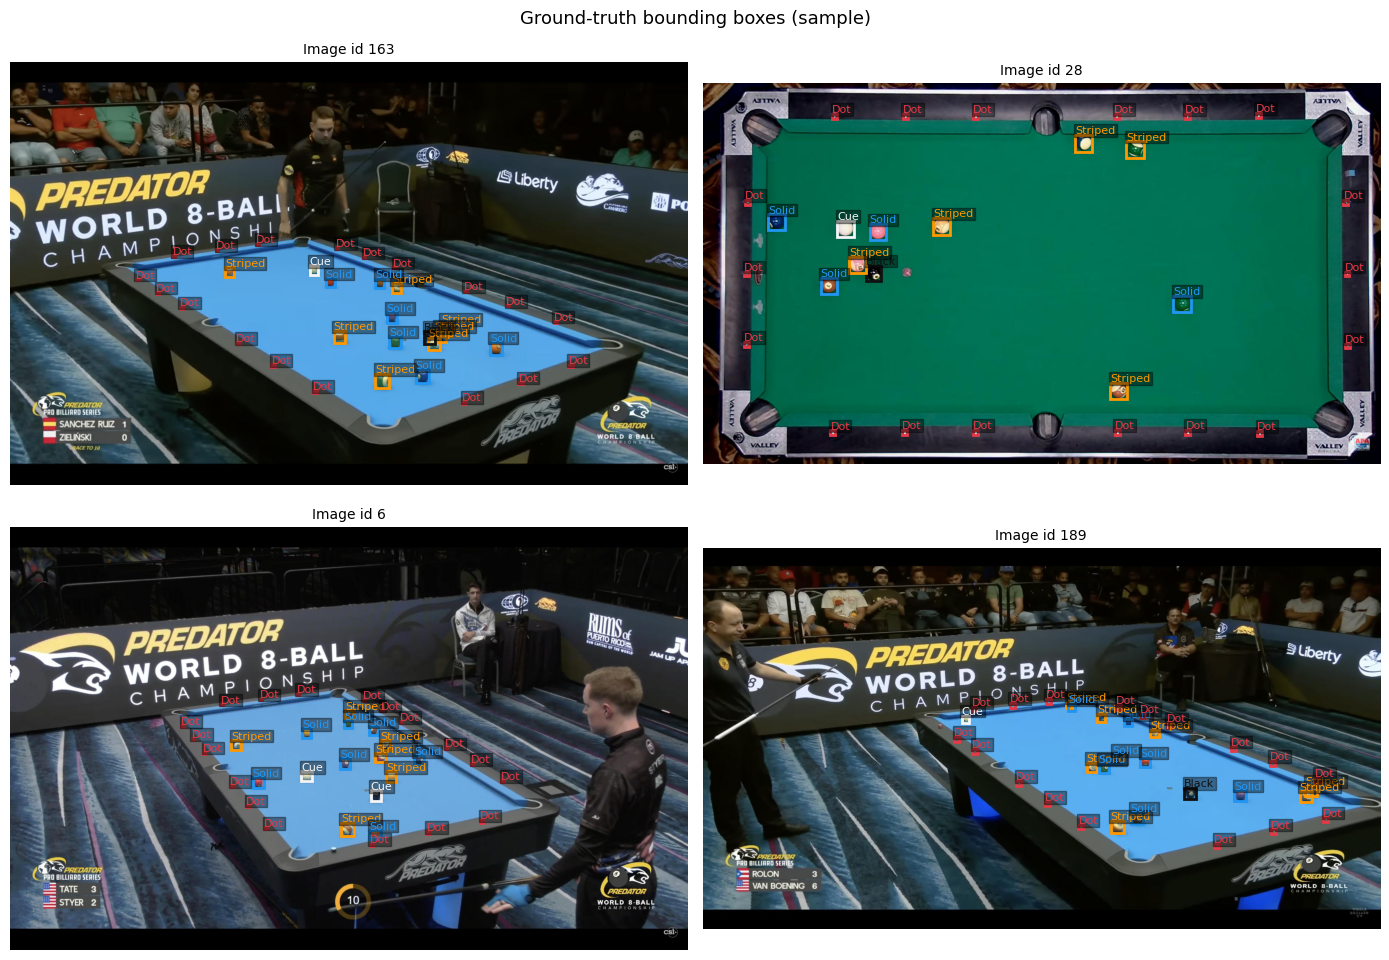

In [ ]:
# ── Visualise ground-truth boxes on a few sample images ────────────────────

ann_by_img = {}
for ann in coco["annotations"]:
    if ann["category_id"] not in real_cat_ids:
        continue
    ann_by_img.setdefault(ann["image_id"], []).append(ann)

# Colour palette for each class
PALETTE = {
    "Black"  : "#111111",
    "Cue"    : "#f5f5f5",
    "Dot"    : "#e63946",
    "Solid"  : "#2196f3",
    "Striped": "#ff9800",
}

sample_ids = random.sample(list(ann_by_img.keys()), k=4)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, img_id in zip(axes.flat, sample_ids):
    img_path = TRAIN_DIR / id_to_file[img_id]
    img_bgr  = cv2.imread(str(img_path))
    img_rgb  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    ax.imshow(img_rgb)

    for ann in ann_by_img[img_id]:
        x, y, w, h = ann["bbox"]          # COCO bbox: [x_min, y_min, width, height]
        cat_name   = id_to_name[ann["category_id"]]
        color      = PALETTE.get(cat_name, "lime")
        rect = patches.Rectangle(
            (x, y), w, h,
            linewidth=2, edgecolor=color, facecolor="none"
        )
        ax.add_patch(rect)
        ax.text(x, y - 4, cat_name, color=color, fontsize=8,
                bbox=dict(facecolor="black", alpha=0.4, pad=1))

    ax.set_title(f"Image id {img_id}", fontsize=10)
    ax.axis("off")

plt.suptitle("Ground-truth bounding boxes (sample)", fontsize=13)
plt.tight_layout()
plt.show()

---
## 2. Data Preparation: COCO → YOLO Format

| Format | Annotation file | Box representation |
|--------|----------------|--------------------|
| COCO   | One big JSON   | `[x_min, y_min, width, height]` in pixels |
| YOLO   | One `.txt` per image | `[class_id, x_center, y_center, width, height]` **normalised 0–1** |


**Split strategy:** 70% train / 15% val / 15% test, stratified at the image level.

In [ ]:
# ── 2.1  Map category name → 0-indexed YOLO class id ───────────────────────

CLASS_NAMES  = sorted([cat["name"] for cat in coco["categories"]
                       if cat["name"] != "balls"])
name_to_yolo = {name: idx for idx, name in enumerate(CLASS_NAMES)}
print("YOLO class mapping:", name_to_yolo)

YOLO class mapping: {'Black': 0, 'Cue': 1, 'Dot': 2, 'Solid': 3, 'Striped': 4}


In [ ]:
# ── 2.2  Create the directory structure expected by Ultralytics ─────────────
#
#   dataset/
#   ├── images/
#   │   ├── train/   
#   │   ├── val/
#   │   └── test/
#   └── labels/
#       ├── train/  
#       ├── val/
#       └── test/

DATASET_DIR = Path("./dataset")

for split in ["train", "val", "test"]:
    (DATASET_DIR / "images" / split).mkdir(parents=True, exist_ok=True)
    (DATASET_DIR / "labels" / split).mkdir(parents=True, exist_ok=True)

print("Directory structure created.")

Directory structure created.


In [ ]:
# ── 2.3  Split image ids into train / val / test ────────────────────────────

all_img_ids = sorted(ann_by_img.keys())
random.shuffle(all_img_ids)

n       = len(all_img_ids)
n_train = int(0.70 * n)
n_val   = int(0.15 * n)
# Test gets the remainder

splits = {
    "train": all_img_ids[:n_train],
    "val"  : all_img_ids[n_train : n_train + n_val],
    "test" : all_img_ids[n_train + n_val :],
}

for split, ids in splits.items():
    print(f"{split:>5}: {len(ids):>4} images")

train:  172 images
  val:   37 images
 test:   38 images


In [ ]:
# ── 2.4  Convert annotations and copy images ────────────────────────────────


# Build a quick lookup: image_id → (width, height)
img_dims = {img["id"]: (img["width"], img["height"]) for img in coco["images"]}

def coco_bbox_to_yolo(bbox, img_w, img_h):
    """Convert COCO [x_min, y_min, w, h] to YOLO [xc, yc, w, h] normalised."""
    x_min, y_min, w, h = bbox
    x_center = (x_min + w / 2) / img_w
    y_center = (y_min + h / 2) / img_h
    return x_center, y_center, w / img_w, h / img_h

for split, img_ids in splits.items():
    for img_id in img_ids:
        img_info  = next(img for img in coco["images"] if img["id"] == img_id)
        fname     = img_info["file_name"]
        img_w, img_h = img_dims[img_id]

        # 1. Copy image
        src = TRAIN_DIR / fname
        dst = DATASET_DIR / "images" / split / fname
        shutil.copy(src, dst)

        # 2. Write label file
        label_path = DATASET_DIR / "labels" / split / (Path(fname).stem + ".txt")
        lines = []
        for ann in ann_by_img.get(img_id, []):
            cat_name = id_to_name[ann["category_id"]]
            class_id = name_to_yolo[cat_name]
            xc, yc, w, h = coco_bbox_to_yolo(ann["bbox"], img_w, img_h)
            # Clamp values to [0, 1] to handle any annotation boundary errors
            xc = max(0.0, min(1.0, xc))
            yc = max(0.0, min(1.0, yc))
            w  = max(0.0, min(1.0, w))
            h  = max(0.0, min(1.0, h))
            lines.append(f"{class_id} {xc:.6f} {yc:.6f} {w:.6f} {h:.6f}")

        label_path.write_text("\n".join(lines))

print("Dataset converted and organised successfully!")

Dataset converted and organised successfully!


In [12]:
# ── 2.5  Write the YAML config file ────────────────────────────────────────
# Ultralytics reads a .yaml file to know where the data lives and
# how many classes exist. This is the only configuration file we need.

yaml_content = f"""# Pool Ball Detection Dataset
path: {DATASET_DIR.resolve()}  # absolute path to dataset root

train: images/train
val:   images/val
test:  images/test

nc: {len(CLASS_NAMES)}  # number of classes
names: {CLASS_NAMES}
"""

yaml_path = Path("pool_balls.yaml")
yaml_path.write_text(yaml_content)
print(yaml_path.read_text())

# Pool Ball Detection Dataset
path: D:\FEUP\AI\Computer vision\CV-TASK2-3\dataset  # absolute path to dataset root

train: images/train
val:   images/val
test:  images/test

nc: 5  # number of classes
names: ['Black', 'Cue', 'Dot', 'Solid', 'Striped']



---
## 3. Model Training


In [ ]:
# ── Training hyperparameters ────────────────────────────────────────────────


EPOCHS    = 20   # number of full passes over the training set
IMG_SIZE  = 640   # resize all images to 640×640 (standard for YOLO)
BATCH     = 8    
DATA_YAML = str(yaml_path.resolve())

print(f"Training config: epochs={EPOCHS}, imgsz={IMG_SIZE}, batch={BATCH}")

Training config: epochs=20, imgsz=640, batch=8


In [ ]:
# ── 3.1  Train YOLOv8-s ─────────────────────────────────────────────────────

print("=" * 60)
print("Training YOLOv8-s...")
print("=" * 60)

yolo_model = YOLO("yolov8s.pt")

yolo_results = yolo_model.train(
    data    = DATA_YAML,
    epochs  = EPOCHS,
    imgsz   = IMG_SIZE,
    batch   = BATCH,
    name    = "yolov8s_pool",   # results saved to runs/detect/yolov8s_pool/
    exist_ok= True,
    verbose = False,            
    device  = 0,
    workers = 0,
)

print("\nYOLOv8-s training complete!")

Training YOLOv8-s...
New https://pypi.org/project/ultralytics/8.4.75 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.60  Python-3.11.1 torch-2.12.0.dev20260408+cu128 CUDA:0 (NVIDIA GeForce RTX 5060 Laptop GPU, 8151MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=D:\FEUP\AI\Computer vision\CV-TASK2-3\pool_balls.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=tr

In [ ]:
# ── 3.2  Train RT-DETR-l ────────────────────────────────────────────────────
.

print("=" * 60)
print("Training RT-DETR-l...")
print("=" * 60)

rtdetr_model = RTDETR("rtdetr-l.pt")

rtdetr_results = rtdetr_model.train(
    data    = DATA_YAML,
    epochs  = EPOCHS,
    imgsz   = 640,
    batch   = 2,              # smaller batch for RT-DETR (heavier model)
    name    = "rtdetr_pool",  # results saved to runs/detect/rtdetr_pool/
    exist_ok= True,
    verbose = False,
     device  = 0,
    workers = 0,
)

print("\nRT-DETR-l training complete!")

Training RT-DETR-l...
New https://pypi.org/project/ultralytics/8.4.75 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.60  Python-3.11.1 torch-2.12.0.dev20260408+cu128 CUDA:0 (NVIDIA GeForce RTX 5060 Laptop GPU, 8151MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=2, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=D:\FEUP\AI\Computer vision\CV-TASK2-3\pool_balls.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=t

c:\Users\Ethan\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\autograd\graph.py:882: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\aten\src\ATen\Context.cpp:164.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


       1/20      6.13G      2.649     0.3633      1.209          2       1280: 100% ━━━━━━━━━━━━ 86/86 1.2s/it 1:471.0sss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 10/10 1.1it/s 9.0s.2s7
                   all         37       1106      0.105      0.403      0.132     0.0562

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
       2/20      6.44G      1.847     0.4283     0.2449          2       1280: 0% ──────────── 0/86  1.5s

c:\Users\Ethan\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\autograd\graph.py:882: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\aten\src\ATen\Context.cpp:164.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


       2/20      6.44G      1.627     0.4324     0.2792          2       1280: 100% ━━━━━━━━━━━━ 86/86 1.1it/s 1:181.0sss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 10/10 4.5it/s 2.2s.2s
                   all         37       1106      0.553      0.358      0.236      0.133

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
       3/20      6.47G      1.456      0.487     0.2184          2       1280: 0% ──────────── 0/86  1.1s

...

      18/20       2.4G     0.5827     0.5058    0.02311          2        640: 100% ━━━━━━━━━━━━ 86/86 1.2it/s 1:120.7sss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 10/10 5.0it/s 2.0s.2s
                   all         37       1106       0.74      0.812      0.838      0.611

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
      19/20       2.4G     0.5938      0.489    0.03123          2        640: 0% ──────────── 0/86  0.8s

c:\Users\Ethan\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\autograd\graph.py:882: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\aten\src\ATen\Context.cpp:164.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      19/20       2.4G     0.5898      0.475    0.02409          2        640: 100% ━━━━━━━━━━━━ 86/86 1.5it/s 56.0s0.6ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 10/10 5.2it/s 1.9s.2s
                   all         37       1106      0.752       0.82      0.846      0.622

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size


c:\Users\Ethan\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\autograd\graph.py:882: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\aten\src\ATen\Context.cpp:164.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      20/20       2.4G     0.5819     0.4734    0.02224          2        640: 100% ━━━━━━━━━━━━ 86/86 1.6it/s 54.3s0.6ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 10/10 5.1it/s 1.9s.2s
                   all         37       1106      0.766      0.835      0.856      0.634

20 epochs completed in 0.481 hours.
Optimizer stripped from D:\FEUP\AI\Computer vision\CV-TASK2-3\runs\detect\rtdetr_pool\weights\last.pt, 66.2MB
Optimizer stripped from D:\FEUP\AI\Computer vision\CV-TASK2-3\runs\detect\rtdetr_pool\weights\best.pt, 66.2MB

Validating D:\FEUP\AI\Computer vision\CV-TASK2-3\runs\detect\rtdetr_pool\weights\best.pt...
Ultralytics 8.4.60  Python-3.11.1 torch-2.12.0.dev20260408+cu128 CUDA:0 (NVIDIA GeForce RTX 5060 Laptop GPU, 8151MiB)
rt-detr-l summary: 310 layers, 31,994,015 parameters, 0 gradients, 103.5 GFLOPs
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 10/

---
## 4. Evaluation






In [16]:
# ── 4.1  Load best weights and run evaluation on test set ──────────────────

YOLO_BEST   = Path("runs/detect/yolov8s_pool/weights/best.pt")
RTDETR_BEST = Path("runs/detect/rtdetr_pool/weights/best.pt")

# Load best checkpoints
yolo_eval   = YOLO(str(YOLO_BEST))
rtdetr_eval = RTDETR(str(RTDETR_BEST))

# Evaluate on the test split
print("Evaluating YOLOv8-s on test set...")
yolo_metrics = yolo_eval.val(data=DATA_YAML, split="test")

print("\nEvaluating RT-DETR-l on test set...")
rtdetr_metrics = rtdetr_eval.val(data=DATA_YAML, split="test")

Evaluating YOLOv8-s on test set...
Ultralytics 8.4.60  Python-3.11.1 torch-2.12.0.dev20260408+cu128 CUDA:0 (NVIDIA GeForce RTX 5060 Laptop GPU, 8151MiB)
Model summary (fused): 73 layers, 11,127,519 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 659.6203.5 MB/s, size: 154.4 KB)
val: Scanning D:\FEUP\AI\Computer vision\CV-TASK2-3\dataset\labels\test.cache... 38 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 38/38  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 2.2s/it 6.5s2.5s1s
                   all         38       1068      0.878      0.868      0.917      0.692
                 Black         37         37      0.934      0.973      0.967      0.816
                   Cue         38         39      0.941      0.811      0.933      0.781
                   Dot         38        682      0.787      0.743      0.761      0.298
                 Solid         37        166     

In [ ]:
# ── 4.2  Build the comparison table ────────────────────────────────────────


def extract_metrics(metrics):
    """Pull the core numbers out of an Ultralytics val result object."""
    return {
        "Precision"   : round(float(metrics.box.mp),   4),
        "Recall"      : round(float(metrics.box.mr),   4),
        "mAP@50"      : round(float(metrics.box.map50), 4),
        "mAP@50:95"   : round(float(metrics.box.map),  4),
    }

yolo_m   = extract_metrics(yolo_metrics)
rtdetr_m = extract_metrics(rtdetr_metrics)

print(f"{'Metric':<15} {'YOLOv8-s':>12} {'RT-DETR-l':>12}")
print("-" * 42)
for metric in ["Precision", "Recall", "mAP@50", "mAP@50:95"]:
    print(f"{metric:<15} {yolo_m[metric]:>12.4f} {rtdetr_m[metric]:>12.4f}")

Metric              YOLOv8-s    RT-DETR-l
------------------------------------------
Precision             0.8777       0.7054
Recall                0.8678       0.8857
mAP@50                0.9172       0.8702
mAP@50:95             0.6924       0.6669


In [18]:
# ── 4.3  Inference speed comparison ────────────────────────────────────────
# Speed matters for real-time applications.
# We time each model on a single test image (CPU inference to be hardware-agnostic).

import time

test_images = sorted((DATASET_DIR / "images" / "test").glob("*.jpg"))
sample_img  = str(test_images[0])
N_RUNS      = 20  # average over multiple runs for stability

def measure_speed(model, img_path, n_runs=20):
    # Warm-up pass
    model.predict(img_path, verbose=False)
    start = time.perf_counter()
    for _ in range(n_runs):
        model.predict(img_path, verbose=False)
    elapsed = time.perf_counter() - start
    return (elapsed / n_runs) * 1000  # ms per image

yolo_ms   = measure_speed(yolo_eval,   sample_img)
rtdetr_ms = measure_speed(rtdetr_eval, sample_img)

print(f"YOLOv8-s  inference speed : {yolo_ms:.1f} ms/image")
print(f"RT-DETR-l inference speed : {rtdetr_ms:.1f} ms/image")

YOLOv8-s  inference speed : 36.1 ms/image
RT-DETR-l inference speed : 80.9 ms/image


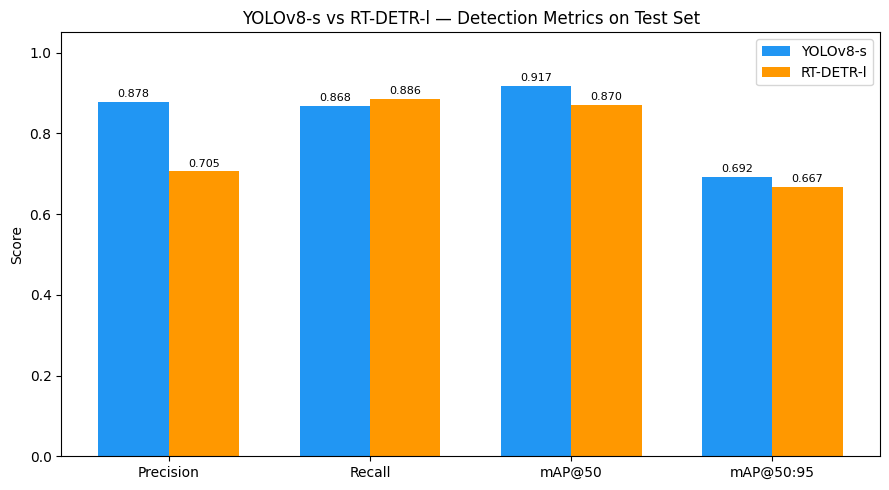

In [19]:
# ── 4.4  Visual comparison bar chart ───────────────────────────────────────

metrics_to_plot = ["Precision", "Recall", "mAP@50", "mAP@50:95"]
yolo_vals   = [yolo_m[m]   for m in metrics_to_plot]
rtdetr_vals = [rtdetr_m[m] for m in metrics_to_plot]

x     = np.arange(len(metrics_to_plot))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, yolo_vals,   width, label="YOLOv8-s",  color="#2196f3")
bars2 = ax.bar(x + width/2, rtdetr_vals, width, label="RT-DETR-l", color="#ff9800")

ax.set_ylabel("Score")
ax.set_title("YOLOv8-s vs RT-DETR-l — Detection Metrics on Test Set")
ax.set_xticks(x)
ax.set_xticklabels(metrics_to_plot)
ax.set_ylim(0, 1.05)
ax.legend()
ax.bar_label(bars1, fmt="%.3f", padding=2, fontsize=8)
ax.bar_label(bars2, fmt="%.3f", padding=2, fontsize=8)

plt.tight_layout()
plt.show()

---
## 5. Qualitative Results




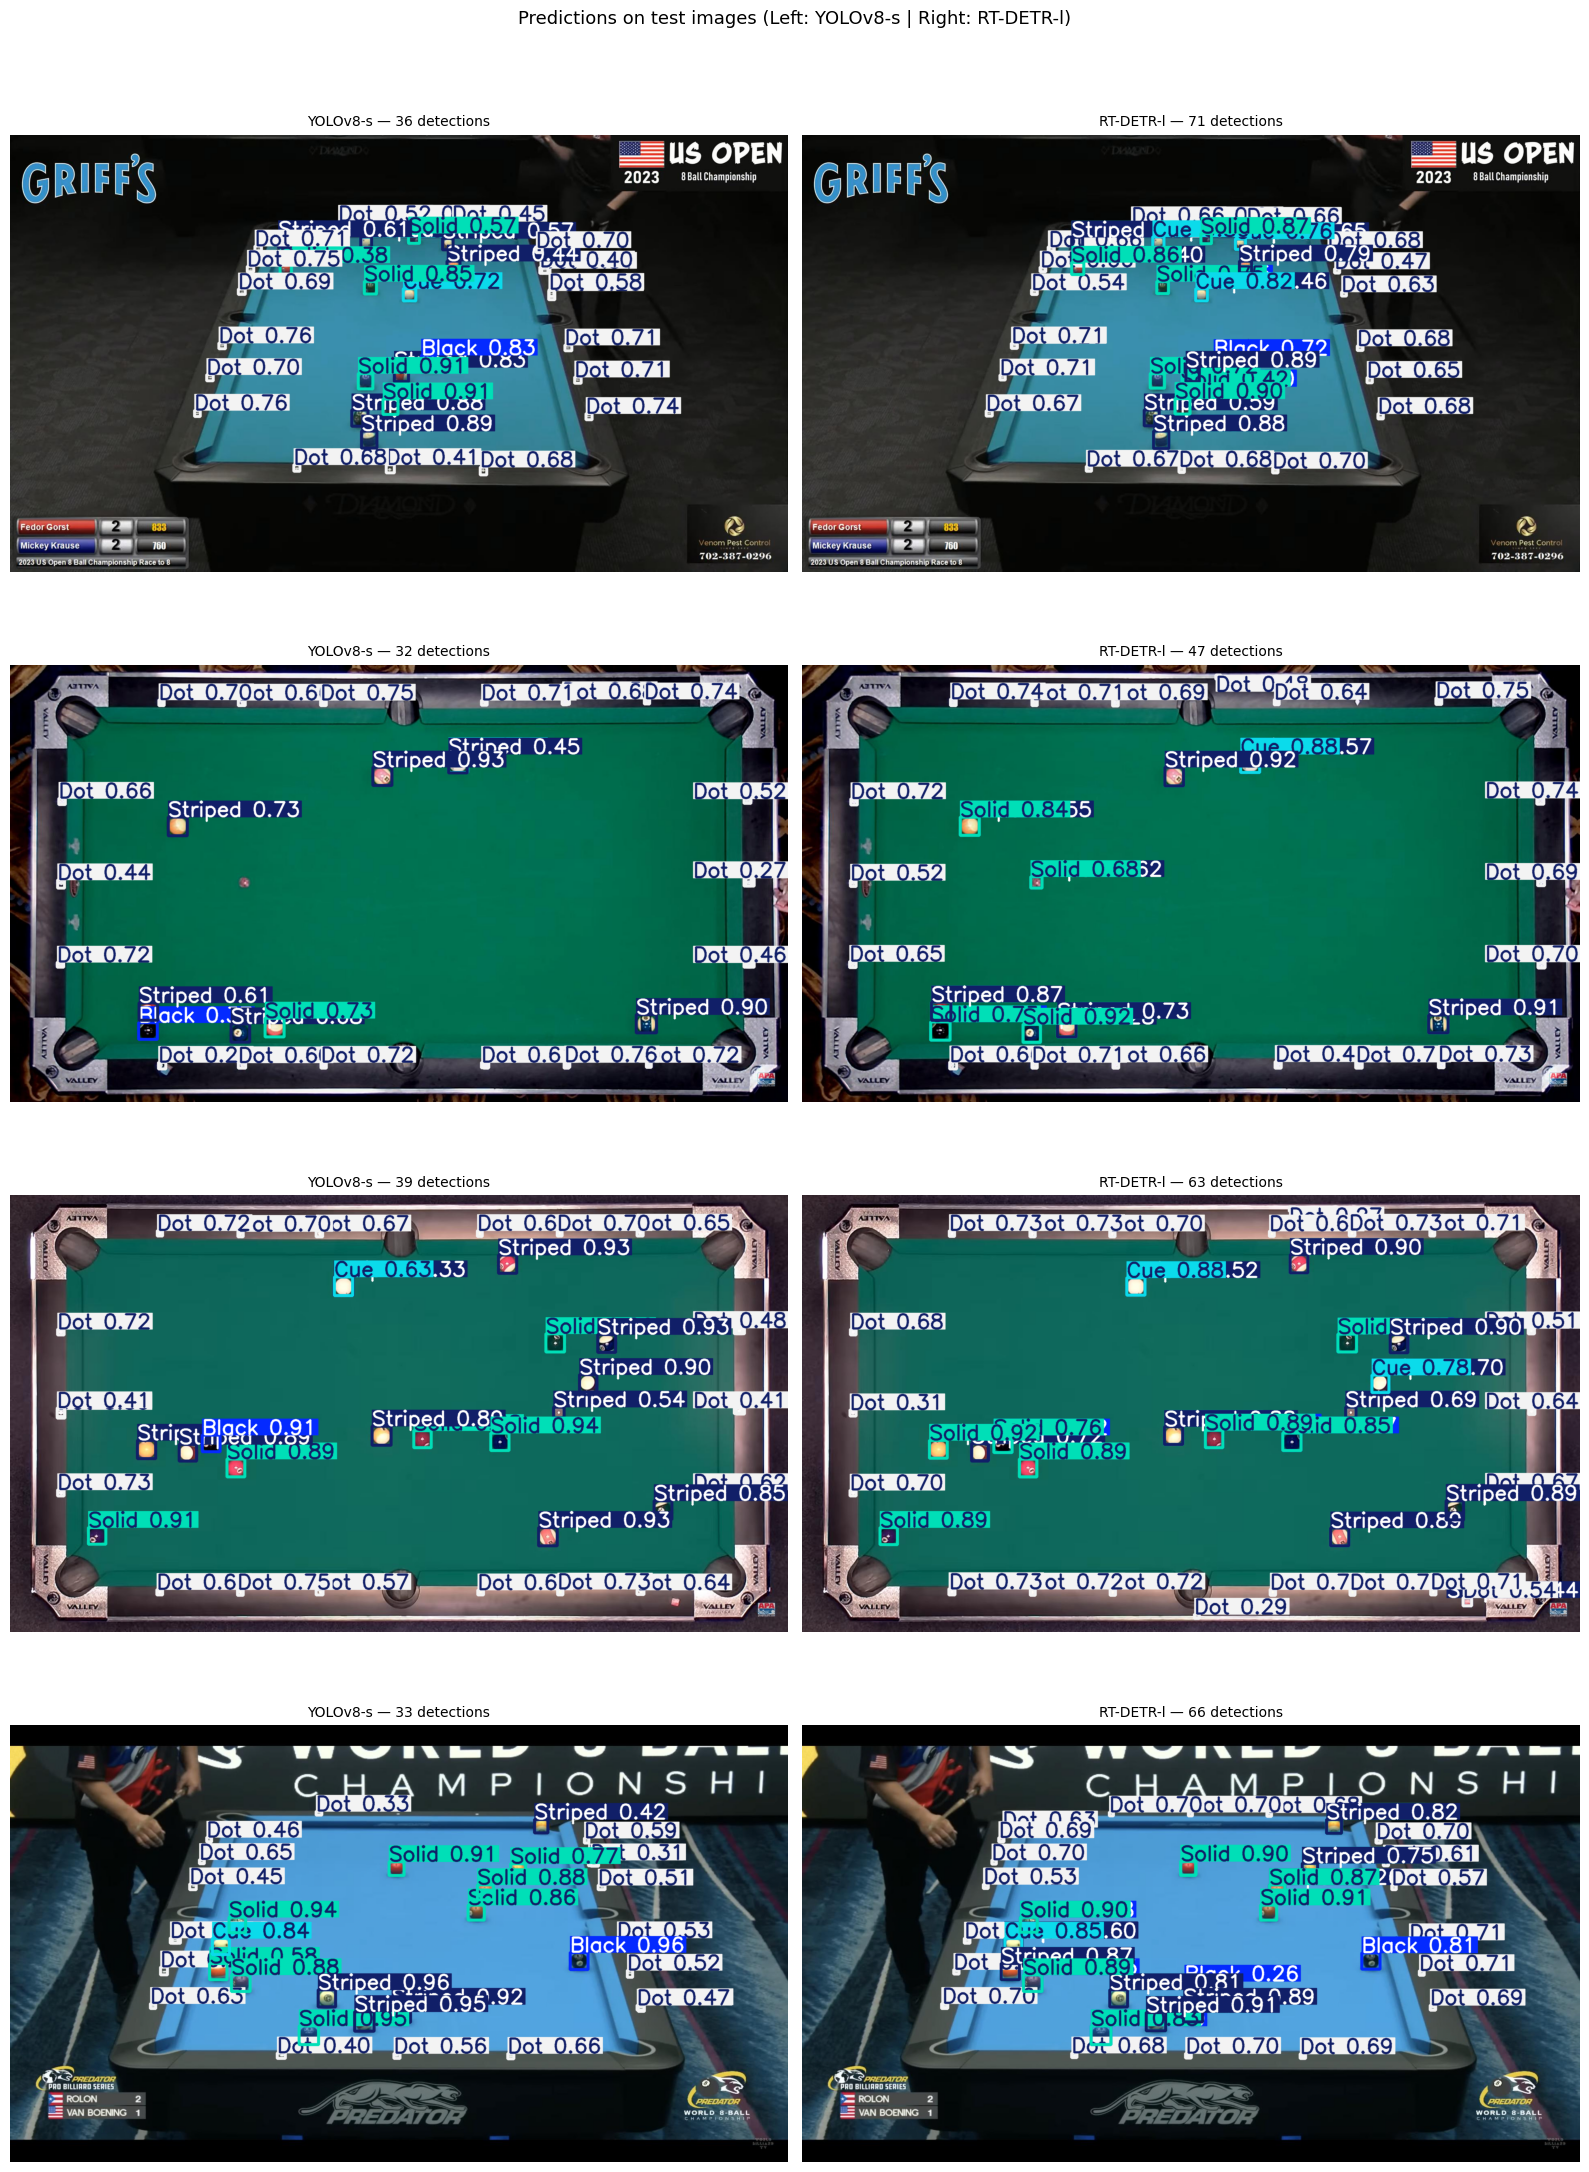

In [20]:
# ── Visualise predictions on 4 test images for each model ──────────────────

CONF_THRESHOLD = 0.25   # only show boxes with confidence ≥ 25%

sample_test = random.sample(test_images, k=4)

fig, axes = plt.subplots(4, 2, figsize=(16, 22))

for row, img_path in enumerate(sample_test):
    for col, (model, model_name) in enumerate([
        (yolo_eval,   "YOLOv8-s"),
        (rtdetr_eval, "RT-DETR-l")
    ]):
        results = model.predict(str(img_path), conf=CONF_THRESHOLD, verbose=False)
        result  = results[0]

        # result.plot() returns a BGR numpy array with boxes drawn
        plotted = result.plot()   # BGR
        plotted = cv2.cvtColor(plotted, cv2.COLOR_BGR2RGB)

        axes[row, col].imshow(plotted)
        n_det = len(result.boxes)
        axes[row, col].set_title(f"{model_name} — {n_det} detections", fontsize=10)
        axes[row, col].axis("off")

plt.suptitle("Predictions on test images (Left: YOLOv8-s | Right: RT-DETR-l)",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

---
## 6. Training Curves



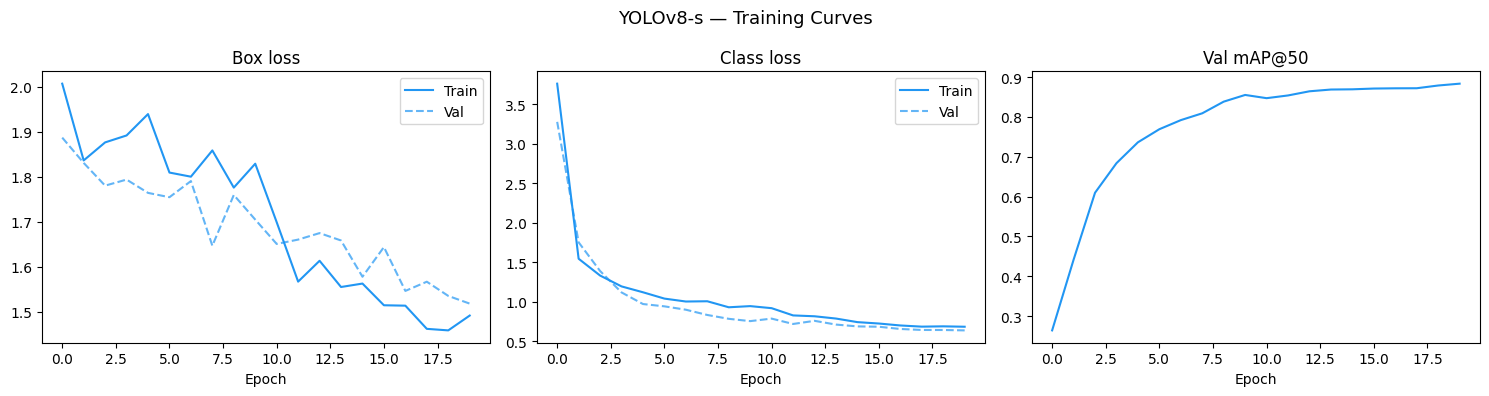

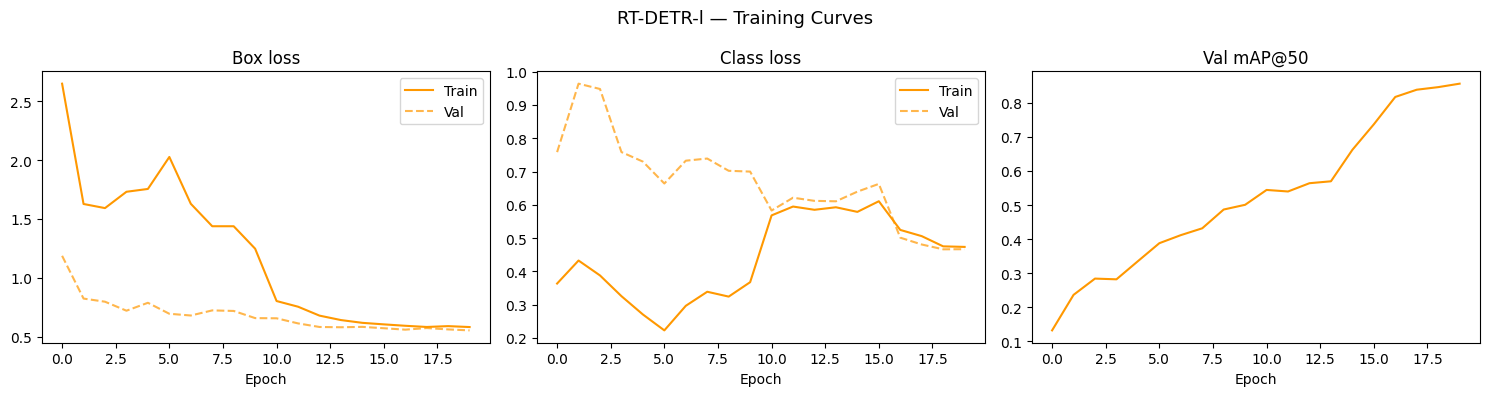

In [ ]:
import pandas as pd

def find_col(df, keywords):
    """Find the first column whose name contains ALL given keywords (case-insensitive).
    YOLOv8 and RT-DETR don't always use identical column names in results.csv,
    so we search instead of hardcoding exact strings."""
    for col in df.columns:
        col_lower = col.lower()
        if all(kw in col_lower for kw in keywords):
            return col
    return None

def plot_training_curves(run_dir, model_name, color):
    csv_path = Path(run_dir) / "results.csv"
    if not csv_path.exists():
        print(f"results.csv not found at {csv_path}")
        return

    df = pd.read_csv(csv_path)
    df.columns = df.columns.str.strip()  
    
    
    train_box_col = find_col(df, ["train", "box"]) or find_col(df, ["train", "giou"]) or find_col(df, ["train", "bbox"])
    val_box_col   = find_col(df, ["val", "box"])   or find_col(df, ["val", "giou"])   or find_col(df, ["val", "bbox"])
    train_cls_col = find_col(df, ["train", "cls"])
    val_cls_col   = find_col(df, ["val", "cls"])
    map50_col     = find_col(df, ["map50"])

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle(f"{model_name} — Training Curves", fontsize=13)

    # Box / localisation loss (train vs val)
    if train_box_col and val_box_col:
        axes[0].plot(df[train_box_col], label="Train", color=color)
        axes[0].plot(df[val_box_col],   label="Val", ls="--", color=color, alpha=0.7)
        axes[0].set_title("Box loss")
        axes[0].set_xlabel("Epoch")
        axes[0].legend()
    else:
        axes[0].set_title("Box loss (column not found)")
        axes[0].axis("off")

    # Class loss
    if train_cls_col and val_cls_col:
        axes[1].plot(df[train_cls_col], label="Train", color=color)
        axes[1].plot(df[val_cls_col],   label="Val", ls="--", color=color, alpha=0.7)
        axes[1].set_title("Class loss")
        axes[1].set_xlabel("Epoch")
        axes[1].legend()
    else:
        axes[1].set_title("Class loss (column not found)")
        axes[1].axis("off")

    # mAP@50
    if map50_col:
        axes[2].plot(df[map50_col], color=color)
        axes[2].set_title("Val mAP@50")
        axes[2].set_xlabel("Epoch")
    else:
        axes[2].set_title("mAP@50 (column not found)")
        axes[2].axis("off")

    plt.tight_layout()
    plt.show()

plot_training_curves("runs/detect/yolov8s_pool",  "YOLOv8-s",  "#2196f3")
plot_training_curves("runs/detect/rtdetr_pool",   "RT-DETR-l", "#ff9800")

---
## 7. Per-Class Analysis



In [ ]:



def per_class_ap(metrics, class_names):
    """Return a dict {class_name: AP@50} from a val result object."""
    ap50_per_class = metrics.box.ap50   # array of AP@50 per class
    return {name: round(float(ap), 4)
            for name, ap in zip(class_names, ap50_per_class)}

yolo_per_class   = per_class_ap(yolo_metrics,   CLASS_NAMES)
rtdetr_per_class = per_class_ap(rtdetr_metrics, CLASS_NAMES)

print(f"{'Class':<10} {'YOLO AP@50':>12} {'RTDETR AP@50':>14}")
print("-" * 40)
for cls in CLASS_NAMES:
    print(f"{cls:<10} {yolo_per_class[cls]:>12.4f} {rtdetr_per_class[cls]:>14.4f}")

Class        YOLO AP@50   RTDETR AP@50
----------------------------------------
Black            0.9665         0.8134
Cue              0.9328         0.9109
Dot              0.7610         0.7743
Solid            0.9737         0.9168
Striped          0.9520         0.9358


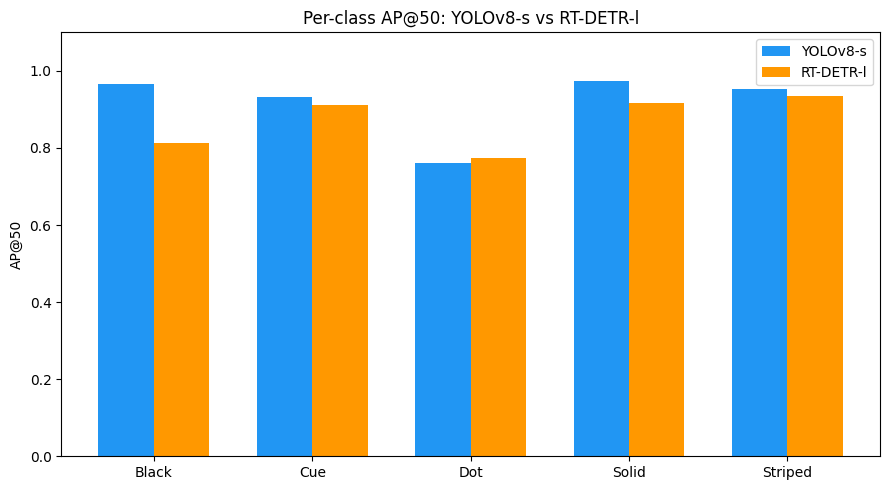

In [23]:
# ── Per-class bar chart ─────────────────────────────────────────────────────
x     = np.arange(len(CLASS_NAMES))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width/2, [yolo_per_class[c]   for c in CLASS_NAMES], width,
       label="YOLOv8-s",  color="#2196f3")
ax.bar(x + width/2, [rtdetr_per_class[c] for c in CLASS_NAMES], width,
       label="RT-DETR-l", color="#ff9800")

ax.set_ylabel("AP@50")
ax.set_title("Per-class AP@50: YOLOv8-s vs RT-DETR-l")
ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES)
ax.set_ylim(0, 1.1)
ax.legend()
plt.tight_layout()
plt.show()

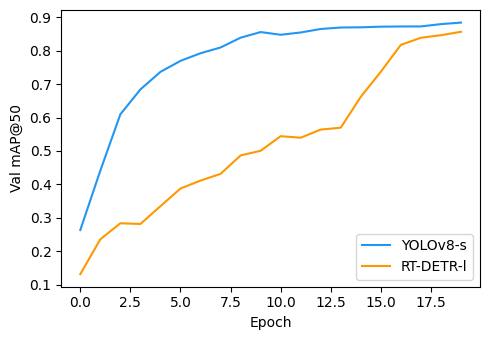

In [ ]:
# ── Plot mAP@50 training curves for both models ─────────────────────────
yolo_df   = pd.read_csv("runs/detect/yolov8s_pool/results.csv")
rtdetr_df = pd.read_csv("runs/detect/rtdetr_pool/results.csv")
yolo_df.columns   = yolo_df.columns.str.strip()
rtdetr_df.columns = rtdetr_df.columns.str.strip()

yolo_map50_col   = find_col(yolo_df, ["map50"])
rtdetr_map50_col = find_col(rtdetr_df, ["map50"])

fig, ax = plt.subplots(figsize=(5, 3.5))
ax.plot(yolo_df[yolo_map50_col],     label="YOLOv8-s",  color="#2196f3")
ax.plot(rtdetr_df[rtdetr_map50_col], label="RT-DETR-l", color="#ff9800")
ax.set_xlabel("Epoch")
ax.set_ylabel("Val mAP@50")
ax.legend()
plt.tight_layout()
plt.savefig("map50_comparison.png", dpi=300, bbox_inches="tight")
plt.show()